#**ANOMALLY DETECTION**

#Q1. What is Anomaly Detection? Explain its types (point, contextual, and collective anomalies) with examples.

It is the process of identifying data points, patterns, that deviate significantly from the normal behaviour.

These unsual patterns often include errors, rare events, frauds.

Types -
1. Point Annomalies - A single data point is abnormal comapred to  the rest of the data. Eg - Typically transactions amount ranges from Rs 500 - 5000, one transaction 200000.

2. Contextual Anomalies - A data point is anomalous only in a specific context (time, location, user). Eg - 30 degree in summer is normal, but 30 degree in winter is anomaly


3. Collective Anomalities - A group of data points together is anomalous, even if individual points look normal. Eg - One login in attempt - normal, if 100 login attempsts are made in 1 minute - its an anomaly.



#Q2.  Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of their approach and suitable use cases.


Isolation Forest -
It is a tree based , unsupervised algorithm, and works by isolating data points using random splits. Anomalies are easy to isolate, so they end up with shorter path length trees.

Eg - credit card fraudd detection, network intrusion detection, sensor fault detection.

DBSCAN - Density based clustering algorithm, groups dense regions into clusters, and the points that do not belong to any cluster are labeled as outliers. Eg - GPS trajectory anomalies, loaction based fraud, image or pattern noise detection.

Local Outlier Factor -

Density bsed local comparison method. Compares a points density with neighbours density. Points with much lower loacl density are anomalies.


Suitable Use Cases-

Fraud in specific customer segments, network traffic spikes in one region, anomalous user behaviour in cluster.



#Q3.  What are the key components of a Time Series? Explain each with one example.

A time series is a sequence of data points collected,  or  recorded at regular time intervals.Understanding its importance helps is analysis, forecastig, anomaly detection.

Key compponents

1. Trends - A long term movement of the data over time.It shows overall increase or decrease in  the series. Eg - Montly sales of an e-commerce comapny, increasing year over year due to business growth

2. Seasonality - Regular repeating patterns that occur at fixed intervals. Eg - Ice cream sales peaking in summers and dropping in winter.

3. Cyclical Component -

Fluctuations that occur over longer, irregular periods, often influenced by economic and external factors.


| Component   | Meaning                              | Example                   |
| ----------- | ------------------------------------ | ------------------------- |
| Trend       | Long-term direction                  | Increasing online sales   |
| Seasonality | Repeating pattern at fixed intervals | Festival sales every year |
| Cyclical    | Long-term irregular cycles           | Economic boom & recession |
| Irregular   | Random noise                         | Sudden system failure     |


#Q4. Define Stationary in time series. How can you test and transform a non-stationary series into a stationary one?

A stationary time series is one whose statistical properties remain constant over time. In simple terms, the data's behaviour does not change with time.

A time series is stationary if - mean is constant over time, variance is constant over time

How to transform -
1. Differencing
Removes - trend by subtracting consecutive observations.

2. Log / Power Transformation

Stabilizes variance.
Common transforms:
Log
Square root
Box-Cox
Example:
Log of sales data with increasing variance over time

3. Detrending
Remove trend explicitly using:
Regression
Moving average

4. Seasonal Adjustment
Remove seasonal patterns using:
Seasonal differencing
Time series decomposition

#Q5.  Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in terms of structure and application.


| Model   | Handles Trend | Handles Seasonality | Uses External Variables | Typical Use Case       |
| ------- | ------------- | ------------------- | ----------------------- | ---------------------- |
| AR      | ❌             | ❌                   | ❌                       | Stationary data        |
| MA      | ❌             | ❌                   | ❌                       | Error correction       |
| ARIMA   | ✅             | ❌                   | ❌                       | Trend only             |
| SARIMA  | ✅             | ✅                   | ❌                       | Trend + seasonality    |
| SARIMAX | ✅             | ✅                   | ✅                       | Real-world forecasting |


#Q6. Load a time series dataset (e.g., AirPassengers), plot the original series, and decompose it into trend, seasonality, and residual components



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

df = pd.read_csv('AirPassengers.csv')
df.head()


,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


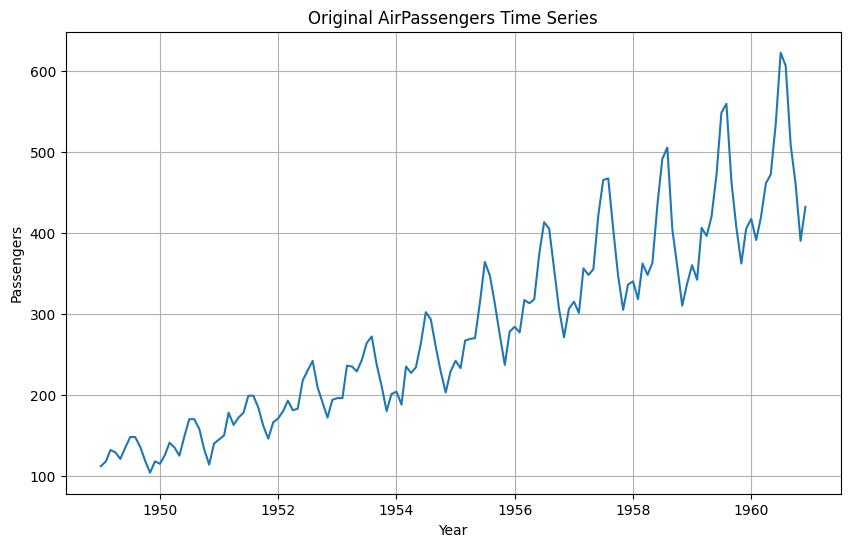

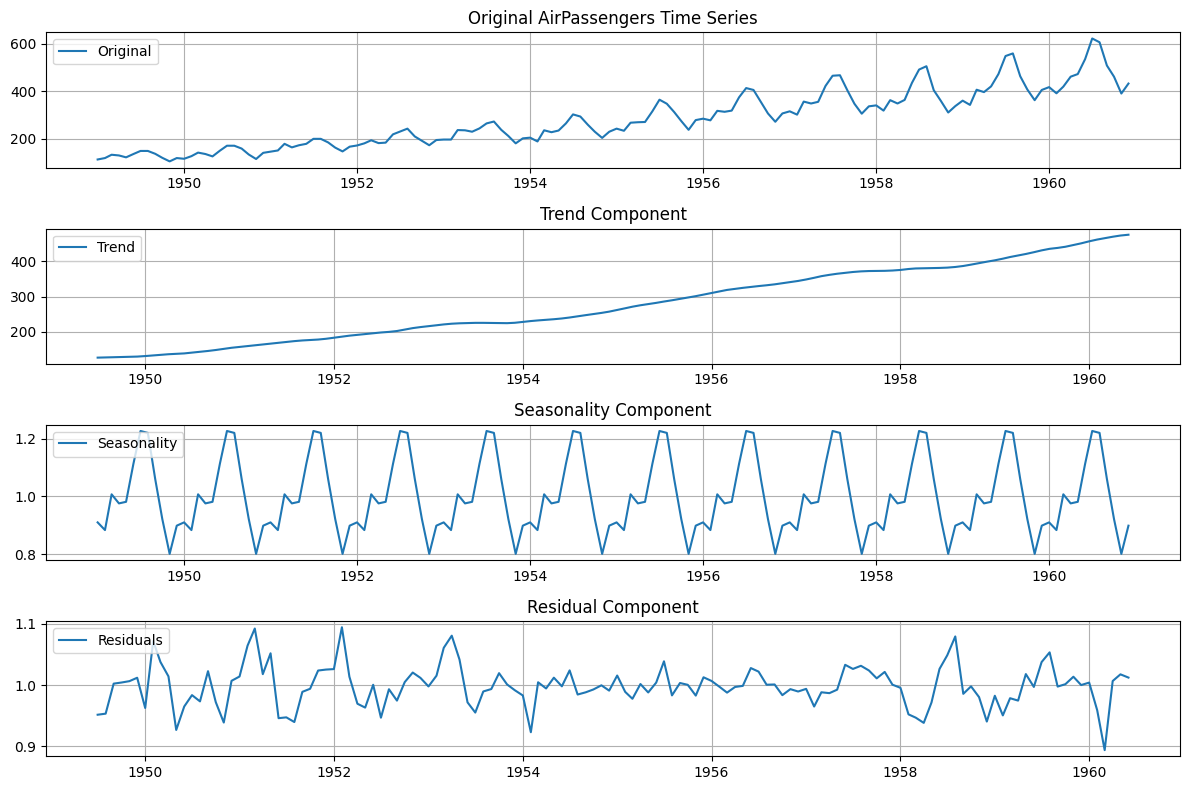

In [3]:
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)
ts = df['#Passengers']
plt.figure(figsize=(10, 6))
plt.plot(ts)
plt.title("Original AirPassengers Time Series")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.grid(True)
plt.show()

# Decompose the time series
decomposition = seasonal_decompose(ts, model="multiplicative", period=12)

plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(ts, label='Original')
plt.legend(loc='upper left')
plt.title("Original AirPassengers Time Series")
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(decomposition.trend, label='Trend')
plt.legend(loc='upper left')
plt.title("Trend Component")
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(decomposition.seasonal, label='Seasonality')
plt.legend(loc='upper left')
plt.title("Seasonality Component")
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(decomposition.resid, label='Residuals')
plt.legend(loc='upper left')
plt.title("Residual Component")
plt.grid(True)

plt.tight_layout()
plt.show()

#Q7.  Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to detect anomalies. Visualize the anomalies on a 2D scatter plot.

In [4]:
df = pd.read_csv('NYC_taxi_fare_data.csv')
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238.0,239.0,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239.0,238.0,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238.0,238.0,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,1,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238.0,151.0,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193.0,193.0,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0


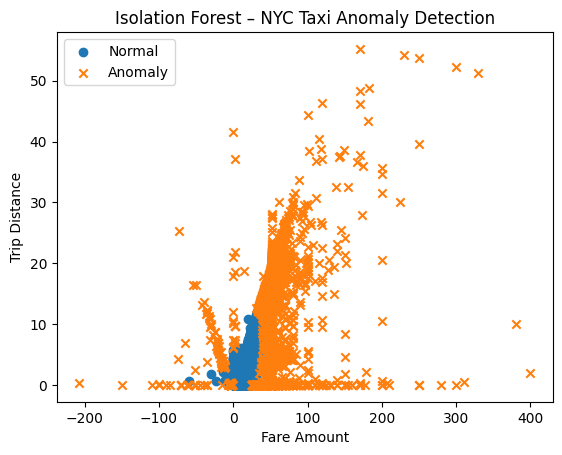

In [6]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

df["anomaly"] = iso.fit_predict(df[["fare_amount", "trip_distance"]])
# 1 = normal, -1 = anomaly


plt.figure()

plt.scatter(
    df[df["anomaly"] == 1]["fare_amount"],
    df[df["anomaly"] == 1]["trip_distance"],
    label="Normal"
)

plt.scatter(
    df[df["anomaly"] == -1]["fare_amount"],
    df[df["anomaly"] == -1]["trip_distance"],
    label="Anomaly",
    marker="x"
)

plt.xlabel("Fare Amount")
plt.ylabel("Trip Distance")
plt.title("Isolation Forest – NYC Taxi Anomaly Detection")
plt.legend()
plt.show()

#Q8. Train a SARIMA model on the monthly airline passengers dataset.Forecast the next 12 months and visualize the results.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


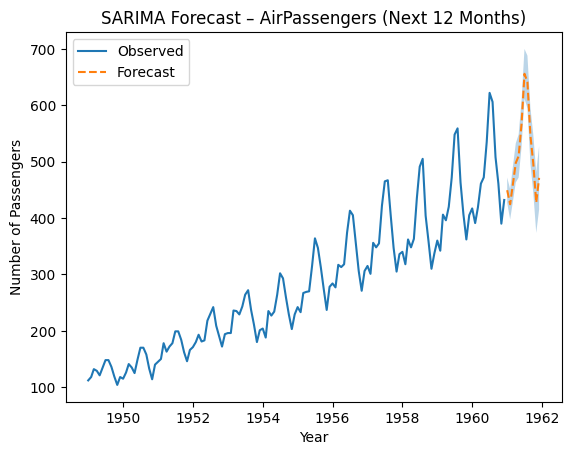

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

df = pd.read_csv("AirPassengers.csv")

# Convert Month column to datetime and set index
df["Month"] = pd.to_datetime(df["Month"])
df.set_index("Month", inplace=True)

ts = df["#Passengers"]
model = SARIMAX(
    ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
)

results = model.fit(disp=False)


#  Forecast next 12 months

forecast_steps = 12
forecast = results.get_forecast(steps=forecast_steps)

forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()


plt.figure()

# Original series
plt.plot(ts, label="Observed")

# Forecast
plt.plot(forecast_mean, label="Forecast", linestyle="--")

# Confidence interval
plt.fill_between(
    forecast_mean.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.3
)

plt.title("SARIMA Forecast – AirPassengers (Next 12 Months)")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")
plt.legend()
plt.show()


#Q9. Apply Local Outlier Factor (LOF) on any numerical dataset to detect anomalies and visualize them using matplotlib.


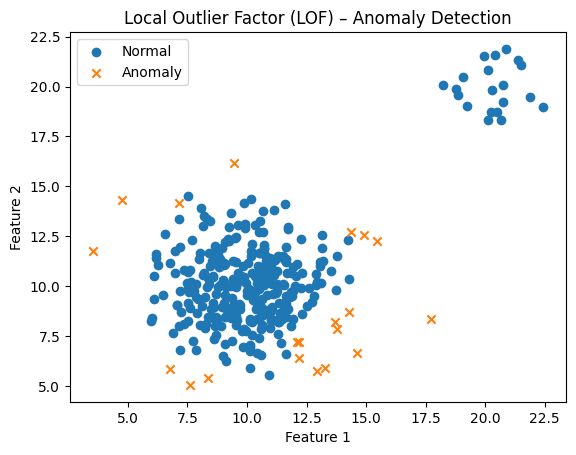

In [8]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor


np.random.seed(42)

# Normal data points
x_normal = np.random.normal(loc=10, scale=2, size=300)
y_normal = np.random.normal(loc=10, scale=2, size=300)

# Anomalous data points
x_anomaly = np.random.normal(loc=20, scale=1, size=20)
y_anomaly = np.random.normal(loc=20, scale=1, size=20)

X = np.concatenate([x_normal, x_anomaly])
Y = np.concatenate([y_normal, y_anomaly])

df = pd.DataFrame({
    "Feature1": X,
    "Feature2": Y
})

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.06
)

df["anomaly"] = lof.fit_predict(df[["Feature1", "Feature2"]])

plt.figure()

# Normal points
plt.scatter(
    df[df["anomaly"] == 1]["Feature1"],
    df[df["anomaly"] == 1]["Feature2"],
    label="Normal"
)

# Anomalies
plt.scatter(
    df[df["anomaly"] == -1]["Feature1"],
    df[df["anomaly"] == -1]["Feature2"],
    label="Anomaly",
    marker="x"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Local Outlier Factor (LOF) – Anomaly Detection")
plt.legend()
plt.show()


#Q10. You are working as a data scientist for a power grid monitoring company.Your goal is to forecast energy demand and also detect abnormal spikes or drops inreal-time consumption data collected every 15 minutes. The dataset includes featureslike timestamp, region, weather conditions, and energy usage.Explain your real-time data science workflow:● How would you detect anomalies in this streaming data (Isolation Forest / LOF /DBSCAN)● Which time series model would you use for short-term forecasting (ARIMA /SARIMA / SARIMAX)?● How would you validate and monitor the performance over time?● How would this solution help business decisions or operations?



I would use Isolation Forest for real-time anomaly detection due to its scalability and effectiveness in detecting sudden spikes or drops. For short-term forecasting, I’d use SARIMAX since energy demand has strong seasonality and depends heavily on weather variables. I’d validate models using rolling windows, monitor drift, and retrain periodically. This system enables early fault detection, demand optimization, and proactive grid management, directly reducing outages and operational costs.